# Validador de Procesos contra Arquetipos y Mapa de Capacidades

Este notebook carga un archivo de actividades de procesos, lo cruza contra el catálogo de arquetipos para identificar a cuál arquetipo pertenece cada código de proceso, y luego busca coincidencias entre las actividades y el mapa de capacidades de procesos.

## 1. Importación de librerías

Se importa `pandas`, la librería principal para manipulación de datos tabulares en este notebook.

In [18]:
import pandas as pd


## 2. Carga del archivo de actividades

Lee el archivo `data/query_actividades_proc_q_actual.csv` y lo carga en el DataFrame `df`.

In [19]:
from pathlib import Path
import pandas as pd

csv_path = Path("data/query_actividades_proc_q_actual.csv")
df = pd.read_csv(csv_path, dtype=str)

print(f"Archivo cargado: {csv_path}")
print(f"{len(df)} filas · {len(df.columns)} columnas")
print(f"Columnas: {list(df.columns)}")
df.head()

Archivo cargado: data\query_actividades_proc_q_actual.csv
39033 filas · 5 columnas
Columnas: ['t1.id_epica', 't1.periodo', 'codigo_proceso', 't2.procedimiento', 't2.actividad']


,t1.id_epica,t1.periodo,codigo_proceso,t2.procedimiento,t2.actividad
0,6788253,2026Q1,FID050210,Definir y ejecutar estrategia de Asset Management,bloqueo usuario
1,6788253,2026Q1,FID050210,Definir y ejecutar estrategia de Asset Management,solicitar impugnación
2,6788253,2026Q1,FID050210,Definir y ejecutar estrategia de Asset Management,solicitar autorización
3,6788253,2026Q1,FID050210,Definir y ejecutar estrategia de Asset Management,s: crear o vincular clientes
4,6788253,2026Q1,FID050210,Definir y ejecutar estrategia de Asset Management,revisión inconsistencias


## 3. Códigos de proceso únicos × Arquetipos (tabla expandida)

Extrae los `codigo_proceso` únicos del CSV de actividades y los cruza contra `arquetipos.csv`.  
El resultado tiene **una fila por cada par (codigo_proceso, arquetipo)**: un proceso puede aparecer en varios arquetipos y un arquetipo puede contener varios procesos.

In [20]:
import sys, os, importlib
sys.path.insert(0, os.getcwd())

import helper.match_arquetipos as _ma
importlib.reload(_ma)
from helper.match_arquetipos import load_arquetipos

# ── Guard: carga df si la celda 2 no fue ejecutada ───────────────────────────
if 'df' not in vars() or 'codigo_proceso' not in df.columns:
    from pathlib import Path
    import pandas as pd
    df = pd.read_csv(Path('data/query_actividades_proc_q_actual.csv'), dtype=str)
    print("(df recargado desde archivos fuente)")

# ── 1. Códigos de proceso únicos ─────────────────────────────────────────────
df_codigos = (
    df[['codigo_proceso']]
    .drop_duplicates()
    .assign(codigo_proceso=lambda x: x['codigo_proceso'].astype(str).str.strip())
    .reset_index(drop=True)
)

# ── 2. Arquetipos explodidos (una fila por código de proceso en el catálogo) ──
_, df_arq_expl = load_arquetipos('data/arquetipos.csv')

arq_code_col = next(c for c in df_arq_expl.columns if 'Código' in c and 'Arquetipo' in c)
arq_name_col = next(c for c in df_arq_expl.columns if 'Nombre' in c and 'Arquetipo' in c)

# ── 3. Left join: conserva todos los códigos, N/A si no hay arquetipo ────────
df_proc_arquetipos = (
    df_codigos
    .merge(
        df_arq_expl[['proc_code', arq_code_col, arq_name_col]].drop_duplicates(),
        left_on='codigo_proceso',
        right_on='proc_code',
        how='left',
    )
    [['codigo_proceso', arq_code_col, arq_name_col]]
    .fillna('N/A')
    .sort_values(['codigo_proceso', arq_code_col])
    .reset_index(drop=True)
)

sin_arquetipo = (df_proc_arquetipos[arq_code_col] == 'N/A').sum()
print(f"Códigos únicos en el CSV:            {df['codigo_proceso'].nunique()}")
print(f"Con al menos un arquetipo asociado:  {df['codigo_proceso'].nunique() - sin_arquetipo}")
print(f"Sin ningún arquetipo (N/A):          {sin_arquetipo}")
print(f"Filas en la tabla expandida:         {len(df_proc_arquetipos)}")
df_proc_arquetipos

Códigos únicos en el CSV:            168
Con al menos un arquetipo asociado:  80
Sin ningún arquetipo (N/A):          88
Filas en la tabla expandida:         187


,codigo_proceso,Código Arquetipo,Nombre Arquetipo
0,FID050210,N/A,N/A
1,FID080105,N/A,N/A
2,PAN040102,ARQ002,Abrir producto
3,PAN040103,ARQ002,Abrir producto
4,PAN040107,ARQ002,Abrir producto
...,...,...,...
182,T160668,N/A,N/A
183,T160669,ARQ002,Abrir producto
184,T160673,ARQ009,Autorizar tokenización
185,T160675,ARQ002,Abrir producto


In [21]:
import os

output_path = 'data/output/proc_arquetipos.csv'
os.makedirs('data/output', exist_ok=True)
df_proc_arquetipos.to_csv(output_path, index=False, encoding='utf-8')
print(f"Guardado en: {output_path}")
print(f"Total de filas: {len(df_proc_arquetipos)}")

Guardado en: data/output/proc_arquetipos.csv
Total de filas: 187


### Gráfico 3 — Cobertura de arquetipos sobre los códigos de proceso únicos

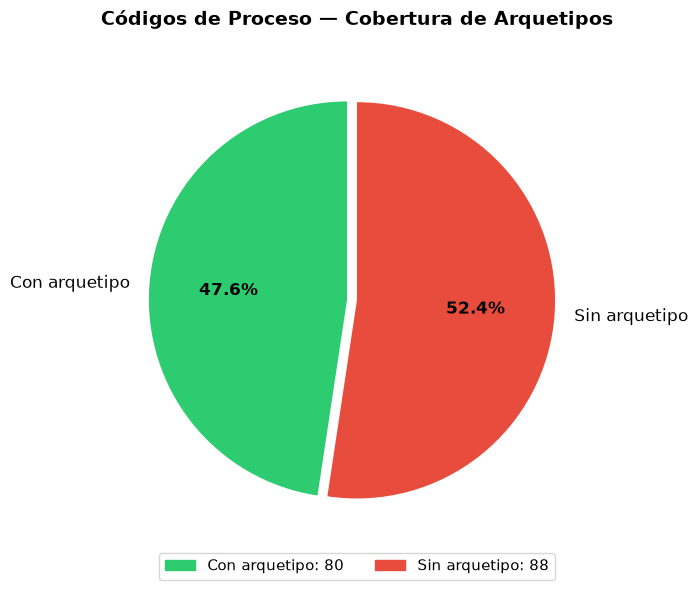

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

total_codigos = df['codigo_proceso'].nunique()
sin_arq       = (df_proc_arquetipos[arq_code_col] == 'N/A').sum()
con_arq       = total_codigos - sin_arq

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    [con_arq, sin_arq],
    labels=['Con arquetipo', 'Sin arquetipo'],
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.05, 0),
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12},
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Códigos de Proceso — Cobertura de Arquetipos', fontsize=14, fontweight='bold', pad=20)
ax.legend(
    handles=[
        mpatches.Patch(color='#2ecc71', label=f'Con arquetipo: {con_arq}'),
        mpatches.Patch(color='#e74c3c', label=f'Sin arquetipo: {sin_arq}'),
    ],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=11,
)
plt.tight_layout()
plt.show()


## 4. Arquetipos × Capacidades de Proceso (tabla expandida)

Cruza los `Nombre Arquetipo` únicos del paso anterior contra el archivo `mapa_capacidades.csv`, evaluando si el nombre del arquetipo aparece **dentro** del campo `Arquetipos Relacionado` (búsqueda por substring, ya que el campo puede contener uno o varios arquetipos).

De cada fila coincidente se extraen:
- `Capacidad de Procesos (Nivel 3)` → renombrado como `capacidades`
- `Dominio`
- `Subdominio Nivel 1`
- `Subdominio Nivel 2`

El resultado `df_arq_capacidades` tiene **una fila por cada par (Nombre Arquetipo, capacidad)**.

In [23]:
import sys, os, importlib, pandas as pd
sys.path.insert(0, os.getcwd())

# ── Guard: reconstruye df_proc_arquetipos si la celda 3 no fue ejecutada ─────
if 'df_proc_arquetipos' not in vars() or 'arq_name_col' not in vars():
    import helper.match_arquetipos as _ma
    importlib.reload(_ma)
    from helper.match_arquetipos import load_arquetipos
    from pathlib import Path

    _df = pd.read_csv(Path('data/query_actividades_proc_q_actual.csv'), dtype=str)
    _, _df_arq_expl = load_arquetipos('data/arquetipos.csv')

    arq_code_col = next(c for c in _df_arq_expl.columns if 'Código' in c and 'Arquetipo' in c)
    arq_name_col = next(c for c in _df_arq_expl.columns if 'Nombre' in c and 'Arquetipo' in c)

    _df_codigos = (
        _df[['codigo_proceso']]
        .drop_duplicates()
        .assign(codigo_proceso=lambda x: x['codigo_proceso'].astype(str).str.strip())
        .reset_index(drop=True)
    )
    df_proc_arquetipos = (
        _df_codigos
        .merge(
            _df_arq_expl[['proc_code', arq_code_col, arq_name_col]].drop_duplicates(),
            left_on='codigo_proceso', right_on='proc_code', how='left',
        )
        [['codigo_proceso', arq_code_col, arq_name_col]]
        .fillna('N/A')
        .reset_index(drop=True)
    )
    print("(df_proc_arquetipos reconstruido desde archivos fuente)")

# ── Carga del mapa de capacidades (UTF-8 con BOM) ────────────────────────────
df_cap = pd.read_csv('data/mapa_capacidades.csv', dtype=str, encoding='utf-8-sig')

_cap_cols = [
    'Capacidad de Procesos (Nivel 3)',
    'Dominio',
    'Subdominio Nivel 1',
    'Subdominio Nivel 2',
    'Arquetipos Relacionado',
]
df_cap_clean = (
    df_cap[_cap_cols]
    .dropna(subset=['Arquetipos Relacionado', 'Capacidad de Procesos (Nivel 3)'])
    .assign(**{'Arquetipos Relacionado': lambda x: x['Arquetipos Relacionado'].str.strip()})
    .reset_index(drop=True)
)

# ── Nombres de arquetipo únicos a buscar (excluye N/A) ───────────────────────
nombres_arq = [n for n in df_proc_arquetipos[arq_name_col].unique() if n != 'N/A']

# ── Cruce por substring: una fila por (arquetipo, capacidad) ─────────────────
fragmentos = []
for nombre in nombres_arq:
    mask = df_cap_clean['Arquetipos Relacionado'].str.contains(nombre, regex=False, na=False)
    coincidencias = df_cap_clean[mask].copy()
    coincidencias['Nombre Arquetipo'] = nombre
    fragmentos.append(coincidencias)

df_arq_capacidades = (
    pd.concat(fragmentos, ignore_index=True)
    .rename(columns={'Capacidad de Procesos (Nivel 3)': 'capacidades'})
    [['Nombre Arquetipo', 'capacidades', 'Dominio', 'Subdominio Nivel 1', 'Subdominio Nivel 2']]
    .drop_duplicates()
    .sort_values(['Nombre Arquetipo', 'capacidades'])
    .reset_index(drop=True)
)

print(f"Arquetipos únicos buscados:          {len(nombres_arq)}")
print(f"Con al menos una capacidad asociada: {df_arq_capacidades['Nombre Arquetipo'].nunique()}")
print(f"Filas en la tabla expandida:         {len(df_arq_capacidades)}")
df_arq_capacidades

Arquetipos únicos buscados:          17
Con al menos una capacidad asociada: 8
Filas en la tabla expandida:         259


,Nombre Arquetipo,capacidades,Dominio,Subdominio Nivel 1,Subdominio Nivel 2
0,Abrir producto,Ajustar parámetro,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...","Tarjeta crédito, tarjeta débito, cheques, reca..."
1,Abrir producto,Asignar sucursal de radicación,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...",NaN
2,Abrir producto,Asociar cuenta al producto,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...","Depósitos a la vista, depósitos a plazo, tarje..."
3,Abrir producto,Asociar producto al cliente,Clientes,Relacionamiento con clientes,Por definir
4,Abrir producto,Asociar producto al cliente,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...",Por definir
...,...,...,...,...,...
254,Realizar Vinculación,Registrar información en fuentes oficiales,Prueba dominio dueño,Prueba sudominio N1,Prueba subdominio N2
255,Realizar Vinculación,Segmentar cliente,Prueba dominio dueño,Prueba sudominio N1,Prueba subdominio N2
256,Realizar Vinculación,Validar procesos de vinculación en curso,Prueba dominio dueño,Prueba sudominio N1,Prueba subdominio N2
257,Realizar Vinculación,Verificar integridad y validez de información ...,Prueba dominio dueño,Prueba sudominio N1,Prueba subdominio N2


In [24]:
import os

output_path = 'data/output/arq_capacidades.csv'
os.makedirs('data/output', exist_ok=True)
df_arq_capacidades.to_csv(output_path, index=False, encoding='utf-8')
print(f"Guardado en: {output_path}")
print(f"Total de filas: {len(df_arq_capacidades)}")

Guardado en: data/output/arq_capacidades.csv
Total de filas: 259


### Gráfico 4 — Capacidades de proceso asociadas por arquetipo

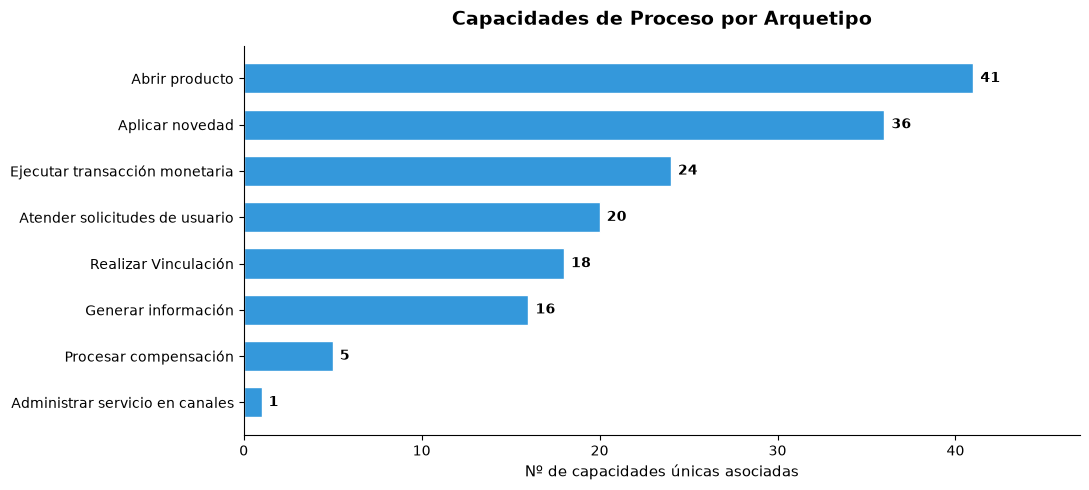

In [25]:
import matplotlib.pyplot as plt

cap_por_arq = (
    df_arq_capacidades
    .groupby('Nombre Arquetipo')['capacidades']
    .nunique()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, max(5, len(cap_por_arq) * 0.5)))

bars = ax.barh(cap_por_arq.index, cap_por_arq.values, color='#3498db', edgecolor='white', height=0.65)

for bar, val in zip(bars, cap_por_arq.values):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Nº de capacidades únicas asociadas', fontsize=11)
ax.set_title('Capacidades de Proceso por Arquetipo', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, cap_por_arq.max() + 6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 4b. Actividades con correspondencia en Capacidades (trazabilidad)

Antes de agregar métricas, se identifica exactamente qué actividades de cada procedimiento tienen match con algún valor del campo `capacidades` generado en el paso 4.

- La búsqueda es normalizada (minúsculas, sin punto final) y evalúa **dos modalidades**:
  - **Exacta**: `actividad == capacidad`
  - **Contenida**: `actividad ⊂ capacidad` (la actividad aparece dentro del texto de la capacidad)
- ⚠️ La dirección `capacidad ⊂ actividad` fue descartada: genera falsos positivos cuando el nombre de una capacidad corta (ej. `"generar documento"`) aparece como substring de una actividad con prefijo distinto (ej. `"cmp 546 generar documento"`).
- Se conservan únicamente las filas con match encontrado, con una fila por actividad única cubierta.
- El resultado `df_actividades_con_match` es persistido en `data/output/` para trazabilidad y auditoría, y es reutilizado directamente por el paso 5.

In [26]:
import pandas as pd, sys, os, importlib

# ── Toggle de matching ────────────────────────────────────────────────────────
# False (default): solo match exacto (actividad == capacidad)
# True           : exacto + contenida (actividad ⊂ capacidad)
MATCH_CONTENIDA = False

# ── Guard: reconstruye df_arq_capacidades si la celda 4 no fue ejecutada ─────
if 'df_arq_capacidades' not in vars():
    sys.path.insert(0, os.getcwd())
    import helper.match_arquetipos as _ma; importlib.reload(_ma)
    from helper.match_arquetipos import load_arquetipos
    from pathlib import Path

    _df_raw = pd.read_csv(Path('data/query_actividades_proc_q_actual.csv'), dtype=str)
    _, _arq_expl = load_arquetipos('data/arquetipos.csv')
    _name_col = next(c for c in _arq_expl.columns if 'Nombre' in c and 'Arquetipo' in c)
    _code_col = next(c for c in _arq_expl.columns if 'Código' in c and 'Arquetipo' in c)
    _df_proc = (
        _df_raw[['codigo_proceso']].drop_duplicates()
        .assign(codigo_proceso=lambda x: x['codigo_proceso'].astype(str).str.strip())
        .merge(_arq_expl[['proc_code', _code_col, _name_col]].drop_duplicates(),
               left_on='codigo_proceso', right_on='proc_code', how='left')
        [[_name_col]].fillna('N/A')
    )
    _names = [n for n in _df_proc[_name_col].unique() if n != 'N/A']
    _cap = pd.read_csv('data/mapa_capacidades.csv', dtype=str, encoding='utf-8-sig')
    _cap_clean = (
        _cap[['Capacidad de Procesos (Nivel 3)', 'Dominio', 'Subdominio Nivel 1',
              'Subdominio Nivel 2', 'Arquetipos Relacionado']]
        .dropna(subset=['Arquetipos Relacionado', 'Capacidad de Procesos (Nivel 3)'])
        .assign(**{'Arquetipos Relacionado': lambda x: x['Arquetipos Relacionado'].str.strip()})
    )
    _frags = []
    for _n in _names:
        _m = _cap_clean[_cap_clean['Arquetipos Relacionado'].str.contains(_n, regex=False, na=False)].copy()
        _m['Nombre Arquetipo'] = _n
        _frags.append(_m)
    df_arq_capacidades = (
        pd.concat(_frags, ignore_index=True)
        .rename(columns={'Capacidad de Procesos (Nivel 3)': 'capacidades'})
        [['Nombre Arquetipo', 'capacidades', 'Dominio', 'Subdominio Nivel 1', 'Subdominio Nivel 2']]
        .drop_duplicates().reset_index(drop=True)
    )
    print("(df_arq_capacidades reconstruido desde archivos fuente)")

# ── 1. Normalización ──────────────────────────────────────────────────────────
def _norm(texto):
    if pd.isna(texto) or not str(texto).strip():
        return ''
    return str(texto).strip().lower().rstrip('.')

caps_norm = {_norm(c) for c in df_arq_capacidades['capacidades'].dropna().unique() if _norm(c)}

# ── 2. Actividades únicas por (proceso, procedimiento) ───────────────────────
df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)

df_unique_act = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    .drop_duplicates()
    .reset_index(drop=True)
)

# ── 3. Filtrar actividades con match ─────────────────────────────────────────
def _tiene_match(actividad):
    act = _norm(actividad)
    if not act:
        return False
    if MATCH_CONTENIDA:
        return any(act == cap or act in cap for cap in caps_norm)
    return any(act == cap for cap in caps_norm)

print(f"Modo matching: {'exacto + contenida (act ⊂ cap)' if MATCH_CONTENIDA else 'solo exacto'}")

df_con_match = (
    df_unique_act[df_unique_act['t2.actividad'].apply(_tiene_match)]
    .rename(columns={'t2.actividad': 'match de actividad encontrada'})
    .reset_index(drop=True)
)

# ── 4. Enriquecer con capacidades, Dominio y Subdominios del paso 4 ───────────
df_cap_join = (
    df_arq_capacidades[['capacidades', 'Dominio', 'Subdominio Nivel 1', 'Subdominio Nivel 2']]
    .drop_duplicates()
    .assign(_cap_norm=lambda x: x['capacidades'].apply(_norm))
)

frags_class = []
for act_val in df_con_match['match de actividad encontrada'].unique():
    act_n = _norm(act_val)
    if MATCH_CONTENIDA:
        mask = df_cap_join['_cap_norm'].apply(lambda c: act_n == c or act_n in c)
    else:
        mask = df_cap_join['_cap_norm'].apply(lambda c: act_n == c)
    matched = df_cap_join[mask].copy()
    if not matched.empty:
        matched['match de actividad encontrada'] = act_val
        frags_class.append(matched)

df_clasificacion = (
    pd.concat(frags_class, ignore_index=True)
    .drop(columns=['_cap_norm'])
    .drop_duplicates()
)

df_actividades_con_match = (
    df_con_match
    .merge(df_clasificacion, on='match de actividad encontrada', how='left')
    .drop_duplicates()
    .reset_index(drop=True)
)

# ── 5. Persistir ──────────────────────────────────────────────────────────────
os.makedirs('data/output', exist_ok=True)
output_path = 'data/output/actividades_con_match.csv'
df_actividades_con_match.to_csv(output_path, index=False, encoding='utf-8')

print(f"Actividades únicas con match:        {df_actividades_con_match['match de actividad encontrada'].nunique()}")
print(f"Procesos con al menos un match:      {df_actividades_con_match['codigo_proceso'].nunique()}")
print(f"Filas en el DataFrame enriquecido:   {len(df_actividades_con_match)}")
print(f"Guardado en: {output_path}")
df_actividades_con_match

Modo matching: solo exacto
Actividades únicas con match:        17
Procesos con al menos un match:      13
Filas en el DataFrame enriquecido:   48
Guardado en: data/output/actividades_con_match.csv


,codigo_proceso,t2.procedimiento,match de actividad encontrada,capacidades,Dominio,Subdominio Nivel 1,Subdominio Nivel 2
0,T050402,T050402 Gestionar requerimientos legal desemba...,aplicar reglas de negocio,Aplicar reglas de negocio,Gestión de la información,Analítica Avanzada,Analítica descriptiva
1,T050402,T050402 Gestionar requerimientos legal desemba...,aplicar reglas de negocio,Aplicar reglas de negocio,Estrategia de los negocios,Modelo de Precio (pricing),No aplica
2,T050402,T050402 Gestionar requerimientos legal desemba...,aplicar reglas de negocio,Aplicar reglas de negocio,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...",Analítica descriptiva
3,T050402,Gestionar requerimientos legal desembargo sobr...,aplicar reglas de negocio,Aplicar reglas de negocio,Gestión de la información,Analítica Avanzada,Analítica descriptiva
4,T050402,Gestionar requerimientos legal desembargo sobr...,aplicar reglas de negocio,Aplicar reglas de negocio,Estrategia de los negocios,Modelo de Precio (pricing),No aplica
5,T050402,Gestionar requerimientos legal desembargo sobr...,aplicar reglas de negocio,Aplicar reglas de negocio,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...",Analítica descriptiva
6,T081001,Reversar comisión e IVA de comisión,consultar información,Consultar información,Prueba dominio dueño,Prueba sudominio N1,Prueba subdominio N2
7,T160667,Administrar Información de Ecosistemas,almacenar información,Almacenar información,Estrategia de los negocios,Modelo de Precio (pricing),No aplica
8,T160667,Administrar Información de Ecosistemas,almacenar información,Almacenar información,Gestión de la información,Analítica Avanzada,Analítica descriptiva
9,T160667,Administrar Información de Ecosistemas,almacenar información,Almacenar información,"Negocios, habilitadores de los negocios","Captaciones, medios de pago, soluciones para e...",Analítica descriptiva


## 5. Cobertura de actividades vs. Capacidades de Proceso

Agrupa el resultado del paso 4b para calcular métricas de cobertura por `codigo_proceso` + `t2.procedimiento`.

- **total actividades**: actividades distintas del procedimiento (sobre el CSV original).
- **# match encontradas**: actividades distintas con cobertura (desde `df_actividades_con_match`).
- **% match actividad/capacidades**: `# match / total actividades`.

In [27]:
import pandas as pd, os

# ── Guard: carga df_actividades_con_match desde CSV si el paso 4b no corrió ──
if 'df_actividades_con_match' not in vars():
    df_actividades_con_match = pd.read_csv(
        'data/output/actividades_con_match.csv', dtype=str
    )
    print("(df_actividades_con_match cargado desde data/output/actividades_con_match.csv)")

# ── 1. Total de actividades distintas por (proceso, procedimiento) ────────────
df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)

total_act = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    .drop_duplicates()
    .groupby(['codigo_proceso', 't2.procedimiento'])['t2.actividad']
    .nunique()
    .rename('total actividades')
)

# ── 2. Matches distintos por (proceso, procedimiento) — desde paso 4b ─────────
match_act = (
    df_actividades_con_match
    .groupby(['codigo_proceso', 't2.procedimiento'])['match de actividad encontrada']
    .nunique()
    .rename('# match encontradas')
)

# ── 3. Unir y calcular porcentaje ─────────────────────────────────────────────
cobertura = (
    total_act.to_frame()
    .join(match_act, how='left')
    .fillna({'# match encontradas': 0})
    .assign(**{'# match encontradas': lambda x: x['# match encontradas'].astype(int)})
    .assign(**{'% match actividad/capacidades': lambda x:
        (x['# match encontradas'] / x['total actividades'] * 100).round(1).astype(str) + '%'})
    .reset_index()
    .sort_values(['codigo_proceso', 't2.procedimiento'])
    .reset_index(drop=True)
)

print(f"Combinaciones (proceso × procedimiento): {len(cobertura)}")
print(f"Con al menos un match:                   {(cobertura['# match encontradas'] > 0).sum()}")
print(f"Sin ningún match:                        {(cobertura['# match encontradas'] == 0).sum()}")
cobertura

Combinaciones (proceso × procedimiento): 808
Con al menos un match:                   20
Sin ningún match:                        788


,codigo_proceso,t2.procedimiento,total actividades,# match encontradas,% match actividad/capacidades
0,FID050210,Definir y ejecutar estrategia de Asset Management,61,0,0.0%
1,FID080105,Controlar y Monitorear Políticas y Límites Rie...,12,0,0.0%
2,PAN040102,Abrir Producto de Crédito,4,0,0.0%
3,PAN040102,Autorizar Operaciones por Callback,6,0,0.0%
4,PAN040102,Crear Cuenta y Autorizar desembolsos,55,0,0.0%
...,...,...,...,...,...
803,T160675,Personalizar y entregar Código QR,19,0,0.0%
804,VAL080512,"Asesorar, negociar o promover operaciones con ...",70,0,0.0%
805,VAL080512,Habilitar comerciales mesa de dinero,7,0,0.0%
806,VAL080512,Procedimiento asesorar clientes MK Valores y F...,30,0,0.0%


In [28]:
import os

output_path = 'data/output/cobertura_actividades_capacidades.csv'
os.makedirs('data/output', exist_ok=True)
cobertura.to_csv(output_path, index=False, encoding='utf-8')
print(f"Guardado en: {output_path}")
print(f"Total de filas: {len(cobertura)}")

Guardado en: data/output/cobertura_actividades_capacidades.csv
Total de filas: 808


## 6. Búsqueda directa en mapa de capacidades para actividades sin cobertura

Complementa el paso 4b buscando matches en actividades que **no** fueron cubiertas previamente.

**Flujo:**
1. Se excluyen de `df_act` todas las `t2.actividad` que ya aparecen como `match de actividad encontrada` en el paso 4b.
2. Sobre el conjunto restante, se realiza una comparación **exacta** (tras normalización: minúsculas + sin punto final) entre `t2.actividad` y el campo `Capacidad de Procesos (Nivel 3)` del mapa de capacidades.
3. De cada fila coincidente se extraen: `Capacidad de Procesos (Nivel 3)`, `Dominio`, `Subdominio Nivel 1`, `Subdominio Nivel 2` y `Arquetipos Relacionado`.

El resultado se persiste en `data/output/cumplimient_parcial_capacidades.csv`.

In [29]:
import pandas as pd, os

# ── Guards ────────────────────────────────────────────────────────────────────
if 'df_act' not in vars():
    df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)
    print("(df_act recargado desde CSV)")

if 'df_actividades_con_match' not in vars():
    df_actividades_con_match = pd.read_csv('data/output/actividades_con_match.csv', dtype=str)
    print("(df_actividades_con_match cargado desde data/output/actividades_con_match.csv)")

if 'df_cap' not in vars():
    df_cap = pd.read_csv('data/mapa_capacidades.csv', dtype=str, encoding='utf-8-sig')
    print("(df_cap recargado desde CSV)")

# ── 1. Normalización ──────────────────────────────────────────────────────────
def _norm(texto):
    if pd.isna(texto) or not str(texto).strip():
        return ''
    return str(texto).strip().lower().rstrip('.')

# ── 2. Excluir actividades ya cubiertas en el paso 4b ────────────────────────
matched_acts = set(df_actividades_con_match['match de actividad encontrada'].unique())

df_sin_cobertura = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    [~df_act['t2.actividad'].isin(matched_acts)]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Actividades únicas totales:           {df_act['t2.actividad'].nunique()}")
print(f"Ya cubiertas (paso 4b):               {len(matched_acts)}")
print(f"Sin cobertura (a buscar en mapa):     {df_sin_cobertura['t2.actividad'].nunique()}")

# ── 3. Preparar mapa de capacidades normalizado ───────────────────────────────
_cap_cols = ['Capacidad de Procesos (Nivel 3)', 'Dominio',
             'Subdominio Nivel 1', 'Subdominio Nivel 2', 'Arquetipos Relacionado']

df_cap_norm = (
    df_cap[_cap_cols]
    .dropna(subset=['Capacidad de Procesos (Nivel 3)'])
    .drop_duplicates()
    .assign(_cap_norm=lambda x: x['Capacidad de Procesos (Nivel 3)'].apply(_norm))
)

# ── 4. Match exacto normalizado ───────────────────────────────────────────────
df_sin_cobertura = df_sin_cobertura.assign(
    _act_norm=lambda x: x['t2.actividad'].apply(_norm)
)

df_cumplimiento_parcial = (
    df_sin_cobertura
    .merge(df_cap_norm, left_on='_act_norm', right_on='_cap_norm', how='inner')
    .rename(columns={'t2.actividad': 'match actividad/capacidad'})
    [['codigo_proceso', 't2.procedimiento', 'match actividad/capacidad',
      'Capacidad de Procesos (Nivel 3)', 'Dominio',
      'Subdominio Nivel 1', 'Subdominio Nivel 2', 'Arquetipos Relacionado']]
    .drop_duplicates()
    .sort_values(['codigo_proceso', 't2.procedimiento'])
    .reset_index(drop=True)
)

# ── 5. Persistir ──────────────────────────────────────────────────────────────
os.makedirs('data/output', exist_ok=True)
output_path = 'data/output/cumplimient_parcial_capacidades.csv'
df_cumplimiento_parcial.to_csv(output_path, index=False, encoding='utf-8')

print(f"Nuevos matches encontrados:           {len(df_cumplimiento_parcial)}")
print(f"Procesos con nuevos matches:          {df_cumplimiento_parcial['codigo_proceso'].nunique()}")
print(f"Guardado en: {output_path}")
df_cumplimiento_parcial

Actividades únicas totales:           11168
Ya cubiertas (paso 4b):               17
Sin cobertura (a buscar en mapa):     11151
Nuevos matches encontrados:           68
Procesos con nuevos matches:          34
Guardado en: data/output/cumplimient_parcial_capacidades.csv


,codigo_proceso,t2.procedimiento,match actividad/capacidad,Capacidad de Procesos (Nivel 3),Dominio,Subdominio Nivel 1,Subdominio Nivel 2,Arquetipos Relacionado
0,PAN040102,Autorizar Operaciones por Callback,notificar inconsistencias,Notificar inconsistencias,Negocios,Financiación,Factoring,NaN
1,PAN040102,Crear Cuenta y Autorizar desembolsos,recibir solicitud,Recibir solicitud,Negocios,Financiación,Factoring,NaN
2,PAN040102,Procedimiento Contingente,recibir solicitud,Recibir solicitud,Negocios,Financiación,Factoring,NaN
3,PAN040103,Autorizar Operaciones CallBack,notificar inconsistencias,Notificar inconsistencias,Negocios,Financiación,Factoring,NaN
4,PAN040103,Diagrama 1,notificar inconsistencias,Notificar inconsistencias,Negocios,Financiación,Factoring,NaN
...,...,...,...,...,...,...,...,...
63,T160668,Administrar el servicio Ecosistemas,cerrar caso,Cerrar caso.,Habilitación empresarial,Cumplimiento,NaN,NaN
64,VAL080512,Procedimiento monitorear recomendaciones profe...,obtener información,Obtener información,Canales,Distribución física,NaN,NaN
65,VAL080512,Procedimiento monitorear recomendaciones profe...,obtener información,Obtener información,Canales,Distribución a Distancia,NaN,NaN
66,VAL080512,Procedimiento monitorear recomendaciones profe...,obtener información,Obtener información,Canales,Distribución digital,NaN,NaN


## 6.1 Métricas de cobertura del Paso 6 por proceso × procedimiento

Agrega los resultados del Paso 6 con la misma estructura del Paso 5:

- **actividades sin cobertura previa**: universo evaluado en el Paso 6 — actividades que no tuvieron match en el Paso 4b, agrupadas por `(codigo_proceso, t2.procedimiento)`.
- **match en mapa capacidades**: cuántas de esas actividades encontraron correspondencia exacta en `mapa_capacidades.csv`.
- **% cobertura mapa capacidades**: `match / universo evaluado`.

In [30]:
import pandas as pd, os

# ── Guards ────────────────────────────────────────────────────────────────────
if 'df_act' not in vars():
    df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)
    print("(df_act recargado desde CSV)")

if 'df_actividades_con_match' not in vars():
    df_actividades_con_match = pd.read_csv('data/output/actividades_con_match.csv', dtype=str)
    print("(df_actividades_con_match cargado desde data/output/)")

if 'df_cumplimiento_parcial' not in vars():
    df_cumplimiento_parcial = pd.read_csv('data/output/cumplimient_parcial_capacidades.csv', dtype=str)
    print("(df_cumplimiento_parcial cargado desde data/output/)")

# ── 1. Universo del Paso 6: actividades únicas sin cobertura previa (4b) ─────
matched_4b = set(df_actividades_con_match['match de actividad encontrada'].unique())

universo_paso6 = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    [~df_act['t2.actividad'].isin(matched_4b)]
    .drop_duplicates()
    .groupby(['codigo_proceso', 't2.procedimiento'])['t2.actividad']
    .nunique()
    .rename('actividades sin cobertura previa')
)

# ── 2. Matches del Paso 6 por (proceso, procedimiento) ───────────────────────
match_paso6 = (
    df_cumplimiento_parcial
    .groupby(['codigo_proceso', 't2.procedimiento'])['match actividad/capacidad']
    .nunique()
    .rename('match en mapa capacidades')
)

# ── 3. Unir y calcular porcentaje ─────────────────────────────────────────────
cobertura_paso6 = (
    universo_paso6.to_frame()
    .join(match_paso6, how='left')
    .fillna({'match en mapa capacidades': 0})
    .assign(**{'match en mapa capacidades': lambda x: x['match en mapa capacidades'].astype(int)})
    .assign(**{'% cobertura mapa capacidades': lambda x:
        (x['match en mapa capacidades'] / x['actividades sin cobertura previa'] * 100)
        .round(1).astype(str) + '%'})
    .reset_index()
    .sort_values(['codigo_proceso', 't2.procedimiento'])
    .reset_index(drop=True)
)

# ── 4. Persistir ──────────────────────────────────────────────────────────────
os.makedirs('data/output', exist_ok=True)
output_path = 'data/output/cobertura_paso6_mapa_capacidades.csv'
cobertura_paso6.to_csv(output_path, index=False, encoding='utf-8')

print(f"Combinaciones (proceso × procedimiento): {len(cobertura_paso6)}")
print(f"Con al menos un match en mapa:           {(cobertura_paso6['match en mapa capacidades'] > 0).sum()}")
print(f"Sin ningún match:                        {(cobertura_paso6['match en mapa capacidades'] == 0).sum()}")
print(f"Guardado en: {output_path}")
cobertura_paso6

Combinaciones (proceso × procedimiento): 808
Con al menos un match en mapa:           56
Sin ningún match:                        752
Guardado en: data/output/cobertura_paso6_mapa_capacidades.csv


,codigo_proceso,t2.procedimiento,actividades sin cobertura previa,match en mapa capacidades,% cobertura mapa capacidades
0,FID050210,Definir y ejecutar estrategia de Asset Management,61,0,0.0%
1,FID080105,Controlar y Monitorear Políticas y Límites Rie...,12,0,0.0%
2,PAN040102,Abrir Producto de Crédito,4,0,0.0%
3,PAN040102,Autorizar Operaciones por Callback,6,1,16.7%
4,PAN040102,Crear Cuenta y Autorizar desembolsos,55,1,1.8%
...,...,...,...,...,...
803,T160675,Personalizar y entregar Código QR,19,0,0.0%
804,VAL080512,"Asesorar, negociar o promover operaciones con ...",70,0,0.0%
805,VAL080512,Habilitar comerciales mesa de dinero,7,0,0.0%
806,VAL080512,Procedimiento asesorar clientes MK Valores y F...,30,0,0.0%


## 7. Búsqueda de actividades faltantes en referencia de actividades

### 7.1 — Actividades sin cobertura acumulada

Se excluyen de `df_act` todas las `t2.actividad` que ya tienen cobertura en alguno de los pasos anteriores:
- **Paso 4b**: actividades con match dentro del contexto del arquetipo (`df_actividades_con_match`).
- **Paso 6**: actividades con match directo sobre el mapa de capacidades (`df_cumplimiento_parcial`).

El conjunto resultante son las actividades que **aún no tienen ninguna cobertura identificada**.

### 7.2 — Búsqueda en `actividades_de_referencia.csv` con precedencia código > nombre

Sobre ese conjunto se busca coincidencia aplicando la siguiente regla de precedencia:

| Caso | `t2.actividad` contiene `[xxx]` | Criterio aplicado |
|---|---|---|
| Código embebido | Sí — ej. `radicar solicitud [act246]` | Match **solo** si el token entre corchetes coincide exactamente con `Código`. El match por nombre se **descarta**, aunque coincida. |
| Sin código embebido | No | Match si `Código` aparece como substring de `t2.actividad` **o** `Nombre de la Actividad` aparece como substring de `t2.actividad`. |

**Motivación:** cuando `t2.actividad` lleva un código explícito entre corchetes, ese token es el identificador propio de la actividad. Permitir match por nombre en ese caso genera falsos positivos — nombres genéricos como "Radicar Solicitud" aparecen en múltiples registros de referencia con códigos distintos, haciendo imposible determinar cuál es el correcto sin validar el código.

In [31]:
import pandas as pd, os, re

# ── Guards ────────────────────────────────────────────────────────────────────
if 'df_act' not in vars():
    df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)
    print("(df_act recargado desde CSV)")

if 'df_actividades_con_match' not in vars():
    df_actividades_con_match = pd.read_csv('data/output/actividades_con_match.csv', dtype=str)
    print("(df_actividades_con_match cargado desde data/output/)")

if 'df_cumplimiento_parcial' not in vars():
    df_cumplimiento_parcial = pd.read_csv('data/output/cumplimient_parcial_capacidades.csv', dtype=str)
    print("(df_cumplimiento_parcial cargado desde data/output/)")

# ── Normalización ─────────────────────────────────────────────────────────────
def _norm(texto):
    if pd.isna(texto) or not str(texto).strip():
        return ''
    return str(texto).strip().lower().rstrip('.')

def _extract_embedded_code(actividad):
    """Extrae y normaliza el código entre corchetes en t2.actividad.
    Ej.: 'radicar solicitud [act246]' → 'act246'. Retorna '' si no hay corchetes."""
    m = re.search(r'\[([^\]]+)\]', str(actividad))
    return m.group(1).strip().lower() if m else ''

# ── 7.1 — Actividades sin cobertura acumulada ─────────────────────────────────
covered = (
    set(df_actividades_con_match['match de actividad encontrada'].unique())
    | set(df_cumplimiento_parcial['match actividad/capacidad'].unique())
)

df_sin_cobertura_total = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    [~df_act['t2.actividad'].isin(covered)]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Actividades únicas totales:           {df_act['t2.actividad'].nunique()}")
print(f"Cubiertas (pasos 4b + 6):             {len(covered)}")
print(f"Sin cobertura acumulada:              {df_sin_cobertura_total['t2.actividad'].nunique()}")

# ── 7.2 — Carga del archivo de referencia ─────────────────────────────────────
# El archivo es latin-1 con BOM. Se renombra la primera columna por posición
# para evitar dependencia en la representación exacta de bytes del BOM.
df_ref = pd.read_csv('data/actividades_de_referencia.csv', dtype=str, encoding='latin-1')
df_ref = df_ref.rename(columns={df_ref.columns[0]: 'Código'})

df_ref['_cod_norm'] = df_ref['Código'].apply(_norm)
df_ref['_nom_norm'] = df_ref['Nombre de la Actividad'].apply(_norm)

df_sin_cobertura_total['_act_norm']      = df_sin_cobertura_total['t2.actividad'].apply(_norm)
df_sin_cobertura_total['_embedded_code'] = df_sin_cobertura_total['t2.actividad'].apply(_extract_embedded_code)

# ── 7.3 — Cruce con lógica de precedencia código > nombre ────────────────────
# Regla de precedencia:
#   • CON código embebido ([xxx]) → match SOLO si embedded_code == Código normalizado
#     (comparación exacta). El match por nombre se descarta aunque coincida, ya que
#     el código explícito es el identificador de la actividad y tiene precedencia.
#   • SIN código embebido → código-como-substring O nombre-como-substring.
def _matches(row, cod_n, nom_n):
    emb = row['_embedded_code']
    if emb:
        return bool(cod_n) and emb == cod_n
    act = row['_act_norm']
    return (bool(cod_n) and cod_n in act) or (bool(nom_n) and nom_n in act)

frags = []
for _, ref_row in df_ref.iterrows():
    cod_n = ref_row['_cod_norm']
    nom_n = ref_row['_nom_norm']
    if not cod_n and not nom_n:
        continue
    mask = df_sin_cobertura_total.apply(lambda r: _matches(r, cod_n, nom_n), axis=1)
    matched = df_sin_cobertura_total[mask].copy()
    if not matched.empty:
        matched['Código']                 = ref_row['Código']
        matched['Nombre de la Actividad'] = ref_row['Nombre de la Actividad']
        frags.append(matched)

if frags:
    df_ref_matches = (
        pd.concat(frags, ignore_index=True)
        [['codigo_proceso', 't2.procedimiento', 't2.actividad',
          'Código', 'Nombre de la Actividad']]
        .drop_duplicates()
        .sort_values(['codigo_proceso', 't2.procedimiento'])
        .reset_index(drop=True)
    )
else:
    df_ref_matches = pd.DataFrame(
        columns=['codigo_proceso', 't2.procedimiento', 't2.actividad',
                 'Código', 'Nombre de la Actividad']
    )

# ── 7.4 — Persistir ───────────────────────────────────────────────────────────
os.makedirs('data/output', exist_ok=True)
output_path = 'data/output/actividades_referencia_matches.csv'
df_ref_matches.to_csv(output_path, index=False, encoding='utf-8')

print(f"Matches encontrados:                  {len(df_ref_matches)}")
print(f"Actividades únicas con match:         {df_ref_matches['t2.actividad'].nunique()}")
print(f"Procesos con al menos un match:       {df_ref_matches['codigo_proceso'].nunique()}")
print(f"Guardado en: {output_path}")
df_ref_matches

Actividades únicas totales:           11168
Cubiertas (pasos 4b + 6):             30
Sin cobertura acumulada:              11138
Matches encontrados:                  1742
Actividades únicas con match:         630
Procesos con al menos un match:       151
Guardado en: data/output/actividades_referencia_matches.csv


,codigo_proceso,t2.procedimiento,t2.actividad,Código,Nombre de la Actividad
0,PAN040102,Crear Cuenta y Autorizar desembolsos,m: gestión de servicios corporativos p: custod...,CP1109,Custodiar documento
1,PAN040102,Crear Cuenta y Autorizar desembolsos,ajustar valor [act016],ACT016,Ajustar Valor
2,PAN040102,Crear Cuenta y Autorizar desembolsos,desembolsar crédito [act123],ACT123,Desembolsar CrÃ©dito
3,PAN040102,Crear Cuenta y Autorizar desembolsos,gestionar inconsistencias [act191],ACT191,Gestionar Inconsistencias
4,PAN040102,Crear Cuenta y Autorizar desembolsos,gestionar inconsistencias,ACT191,Gestionar Inconsistencias
...,...,...,...,...,...
1737,VAL080512,Habilitar comerciales mesa de dinero,enviar información [act156],ACT156,Enviar InformaciÃ³n
1738,VAL080512,Procedimiento asesorar clientes MK Valores y F...,enviar información [act156],ACT156,Enviar InformaciÃ³n
1739,VAL080512,Procedimiento asesorar clientes MK Valores y F...,procesar solicitud [act238],ACT238,Procesar Solicitud
1740,VAL080512,Procedimiento asesorar clientes MK Valores y F...,solicitar autorización [act311],ACT311,Solicitar AutorizaciÃ³n


## 7.3 Métricas de cobertura del Paso 7 por proceso × procedimiento

Agrega los resultados del Paso 7 con la misma estructura de los pasos anteriores:

- **actividades sin cobertura acumulada**: universo evaluado en el Paso 7 — actividades que no tuvieron match en el Paso 4b **ni** en el Paso 6, agrupadas por `(codigo_proceso, t2.procedimiento)`.
- **match en referencia actividades**: cuántas de esas actividades encontraron correspondencia en `actividades_de_referencia.csv` (por código embebido o por nombre).
- **% cobertura referencia actividades**: `match / universo evaluado`.

In [32]:
import pandas as pd, os

# ── Guards ────────────────────────────────────────────────────────────────────
if 'df_act' not in vars():
    df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)
    print("(df_act recargado desde CSV)")

if 'df_actividades_con_match' not in vars():
    df_actividades_con_match = pd.read_csv('data/output/actividades_con_match.csv', dtype=str)
    print("(df_actividades_con_match cargado desde data/output/)")

if 'df_cumplimiento_parcial' not in vars():
    df_cumplimiento_parcial = pd.read_csv('data/output/cumplimient_parcial_capacidades.csv', dtype=str)
    print("(df_cumplimiento_parcial cargado desde data/output/)")

if 'df_ref_matches' not in vars():
    df_ref_matches = pd.read_csv('data/output/actividades_referencia_matches.csv', dtype=str)
    print("(df_ref_matches cargado desde data/output/)")

# ── 1. Universo del Paso 7: actividades sin cobertura acumulada (4b + 6) ─────
covered_acum = (
    set(df_actividades_con_match['match de actividad encontrada'].unique())
    | set(df_cumplimiento_parcial['match actividad/capacidad'].unique())
)

universo_paso7 = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    [~df_act['t2.actividad'].isin(covered_acum)]
    .drop_duplicates()
    .groupby(['codigo_proceso', 't2.procedimiento'])['t2.actividad']
    .nunique()
    .rename('actividades sin cobertura acumulada')
)

# ── 2. Matches del Paso 7 por (proceso, procedimiento) ───────────────────────
match_paso7 = (
    df_ref_matches
    .groupby(['codigo_proceso', 't2.procedimiento'])['t2.actividad']
    .nunique()
    .rename('match en referencia actividades')
)

# ── 3. Unir y calcular porcentaje ─────────────────────────────────────────────
cobertura_paso7 = (
    universo_paso7.to_frame()
    .join(match_paso7, how='left')
    .fillna({'match en referencia actividades': 0})
    .assign(**{'match en referencia actividades': lambda x: x['match en referencia actividades'].astype(int)})
    .assign(**{'% cobertura referencia actividades': lambda x:
        (x['match en referencia actividades'] / x['actividades sin cobertura acumulada'] * 100)
        .round(1).astype(str) + '%'})
    .reset_index()
    .sort_values(['codigo_proceso', 't2.procedimiento'])
    .reset_index(drop=True)
)

# ── 4. Persistir ──────────────────────────────────────────────────────────────
os.makedirs('data/output', exist_ok=True)
output_path = 'data/output/cobertura_paso7_referencia_actividades.csv'
cobertura_paso7.to_csv(output_path, index=False, encoding='utf-8')

print(f"Combinaciones (proceso × procedimiento): {len(cobertura_paso7)}")
print(f"Con al menos un match en referencia:     {(cobertura_paso7['match en referencia actividades'] > 0).sum()}")
print(f"Sin ningún match:                        {(cobertura_paso7['match en referencia actividades'] == 0).sum()}")
print(f"Guardado en: {output_path}")
cobertura_paso7

Combinaciones (proceso × procedimiento): 808
Con al menos un match en referencia:     468
Sin ningún match:                        340
Guardado en: data/output/cobertura_paso7_referencia_actividades.csv


,codigo_proceso,t2.procedimiento,actividades sin cobertura acumulada,match en referencia actividades,% cobertura referencia actividades
0,FID050210,Definir y ejecutar estrategia de Asset Management,61,0,0.0%
1,FID080105,Controlar y Monitorear Políticas y Límites Rie...,12,0,0.0%
2,PAN040102,Abrir Producto de Crédito,4,0,0.0%
3,PAN040102,Autorizar Operaciones por Callback,5,0,0.0%
4,PAN040102,Crear Cuenta y Autorizar desembolsos,54,8,14.8%
...,...,...,...,...,...
803,T160675,Personalizar y entregar Código QR,19,0,0.0%
804,VAL080512,"Asesorar, negociar o promover operaciones con ...",70,0,0.0%
805,VAL080512,Habilitar comerciales mesa de dinero,7,1,14.3%
806,VAL080512,Procedimiento asesorar clientes MK Valores y F...,30,4,13.3%


## 8. Tabla consolidada de cobertura global

Une los resultados de los tres pasos de búsqueda en una sola tabla por `codigo_proceso` × `t2.procedimiento`.

Las columnas de porcentaje por paso muestran la **contribución individual** de cada fuente de cobertura sobre el total de actividades del procedimiento, lo que permite comparar qué tan efectivo fue cada mecanismo de búsqueda.

| Grupo de columnas | Descripción |
|---|---|
| `total actividades` | Universo total de actividades únicas del procedimiento en el CSV fuente |
| `match paso 5` / `% paso 5` | Cobertura por arquetipo (Paso 4b) |
| `match paso 6` / `% paso 6` | Cobertura por mapa de capacidades completo (Paso 6) |
| `match paso 7` / `% paso 7` | Cobertura por catálogo de referencia (Paso 7) |
| `total match` | Suma sin duplicados — por diseño, cada paso excluye lo ya cubierto |
| `sin cobertura` | Actividades que no tuvieron match en ningún paso |
| `% cobertura global` | `total match / total actividades` |

In [33]:
import pandas as pd, os

# ── Guards ────────────────────────────────────────────────────────────────────
if 'df_act' not in vars():
    df_act = pd.read_csv('data/query_actividades_proc_q_actual.csv', dtype=str)
    print("(df_act recargado desde CSV)")

if 'df_actividades_con_match' not in vars():
    df_actividades_con_match = pd.read_csv('data/output/actividades_con_match.csv', dtype=str)
    print("(df_actividades_con_match cargado desde data/output/)")

if 'df_cumplimiento_parcial' not in vars():
    df_cumplimiento_parcial = pd.read_csv('data/output/cumplimient_parcial_capacidades.csv', dtype=str)
    print("(df_cumplimiento_parcial cargado desde data/output/)")

if 'df_ref_matches' not in vars():
    df_ref_matches = pd.read_csv('data/output/actividades_referencia_matches.csv', dtype=str)
    print("(df_ref_matches cargado desde data/output/)")

# ── 1. Universo total ─────────────────────────────────────────────────────────
total_act = (
    df_act[['codigo_proceso', 't2.procedimiento', 't2.actividad']]
    .drop_duplicates()
    .groupby(['codigo_proceso', 't2.procedimiento'])['t2.actividad']
    .nunique()
    .rename('total actividades')
)

# ── 2. Matches por paso ───────────────────────────────────────────────────────
match_5 = (
    df_actividades_con_match
    .groupby(['codigo_proceso', 't2.procedimiento'])['match de actividad encontrada']
    .nunique()
    .rename('match paso 5')
)

match_6 = (
    df_cumplimiento_parcial
    .groupby(['codigo_proceso', 't2.procedimiento'])['match actividad/capacidad']
    .nunique()
    .rename('match paso 6')
)

match_7 = (
    df_ref_matches
    .groupby(['codigo_proceso', 't2.procedimiento'])['t2.actividad']
    .nunique()
    .rename('match paso 7')
)

# ── 3. Consolidar ─────────────────────────────────────────────────────────────
def _pct(num, den):
    return (num / den * 100).round(1).astype(str) + '%'

cobertura_global = (
    total_act.to_frame()
    .join(match_5, how='left')
    .join(match_6, how='left')
    .join(match_7, how='left')
    .fillna({'match paso 5': 0, 'match paso 6': 0, 'match paso 7': 0})
    .astype({'match paso 5': int, 'match paso 6': int, 'match paso 7': int})
    .reset_index()
)

cobertura_global['% paso 5'] = _pct(cobertura_global['match paso 5'], cobertura_global['total actividades'])
cobertura_global['% paso 6'] = _pct(cobertura_global['match paso 6'], cobertura_global['total actividades'])
cobertura_global['% paso 7'] = _pct(cobertura_global['match paso 7'], cobertura_global['total actividades'])

cobertura_global['total match']        = cobertura_global[['match paso 5', 'match paso 6', 'match paso 7']].sum(axis=1)
cobertura_global['sin cobertura']      = cobertura_global['total actividades'] - cobertura_global['total match']
cobertura_global['% cobertura global'] = _pct(cobertura_global['total match'], cobertura_global['total actividades'])

cobertura_global = (
    cobertura_global[[
        'codigo_proceso', 't2.procedimiento',
        'total actividades',
        'match paso 5', '% paso 5',
        'match paso 6', '% paso 6',
        'match paso 7', '% paso 7',
        'total match', 'sin cobertura', '% cobertura global',
    ]]
    .sort_values(['codigo_proceso', 't2.procedimiento'])
    .reset_index(drop=True)
)

# ── 4. Persistir ──────────────────────────────────────────────────────────────
os.makedirs('data/output', exist_ok=True)
output_path = 'data/output/cobertura_global.csv'
cobertura_global.to_csv(output_path, index=False, encoding='utf-8')

total_act_sum   = cobertura_global['total actividades'].sum()
total_match_sum = cobertura_global['total match'].sum()
print(f"Combinaciones (proceso × procedimiento): {len(cobertura_global)}")
print(f"Total actividades (suma):                {total_act_sum}")
print(f"Total con cobertura (suma):              {total_match_sum}")
print(f"Cobertura global agregada:               {round(total_match_sum / total_act_sum * 100, 1)}%")
print(f"Guardado en: {output_path}")
cobertura_global

Combinaciones (proceso × procedimiento): 808
Total actividades (suma):                16203
Total con cobertura (suma):              1828
Cobertura global agregada:               11.3%
Guardado en: data/output/cobertura_global.csv


,codigo_proceso,t2.procedimiento,total actividades,match paso 5,% paso 5,match paso 6,% paso 6,match paso 7,% paso 7,total match,sin cobertura,% cobertura global
0,FID050210,Definir y ejecutar estrategia de Asset Management,61,0,0.0%,0,0.0%,0,0.0%,0,61,0.0%
1,FID080105,Controlar y Monitorear Políticas y Límites Rie...,12,0,0.0%,0,0.0%,0,0.0%,0,12,0.0%
2,PAN040102,Abrir Producto de Crédito,4,0,0.0%,0,0.0%,0,0.0%,0,4,0.0%
3,PAN040102,Autorizar Operaciones por Callback,6,0,0.0%,1,16.7%,0,0.0%,1,5,16.7%
4,PAN040102,Crear Cuenta y Autorizar desembolsos,55,0,0.0%,1,1.8%,8,14.5%,9,46,16.4%
...,...,...,...,...,...,...,...,...,...,...,...,...
803,T160675,Personalizar y entregar Código QR,19,0,0.0%,0,0.0%,0,0.0%,0,19,0.0%
804,VAL080512,"Asesorar, negociar o promover operaciones con ...",70,0,0.0%,0,0.0%,0,0.0%,0,70,0.0%
805,VAL080512,Habilitar comerciales mesa de dinero,7,0,0.0%,0,0.0%,1,14.3%,1,6,14.3%
806,VAL080512,Procedimiento asesorar clientes MK Valores y F...,30,0,0.0%,0,0.0%,4,13.3%,4,26,13.3%


### Gráfico 8 — Cobertura global: resumen agregado y top 20 procesos por matches

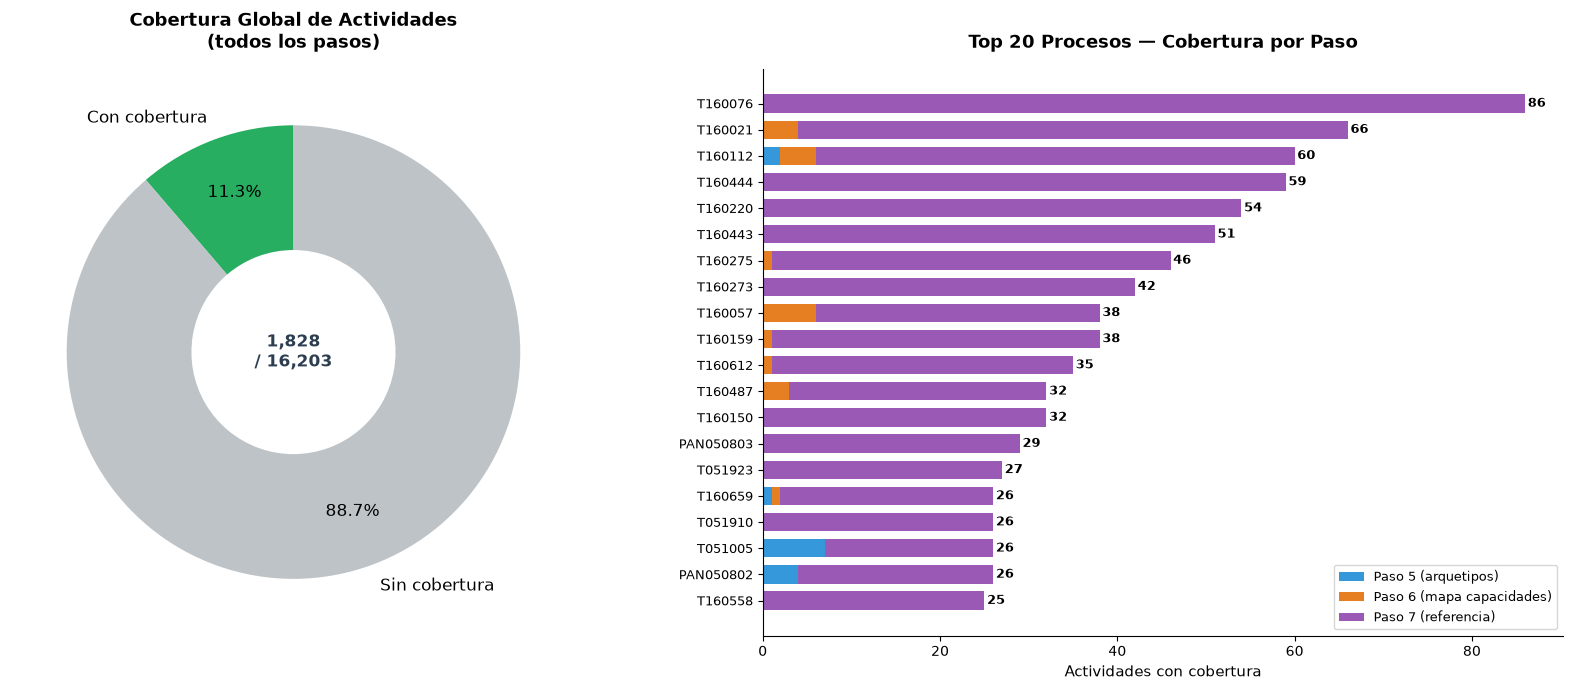

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ── Donut: cobertura global agregada ─────────────────────────────────────────
total_sum   = cobertura_global['total actividades'].sum()
matched_sum = cobertura_global['total match'].sum()
sin_cob_sum = total_sum - matched_sum

ax1 = axes[0]
ax1.pie(
    [matched_sum, sin_cob_sum],
    labels=['Con cobertura', 'Sin cobertura'],
    colors=['#27ae60', '#bdc3c7'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.55},
    textprops={'fontsize': 12},
    pctdistance=0.75,
)
ax1.text(0, 0, f'{matched_sum:,}\n/ {total_sum:,}',
         ha='center', va='center', fontsize=12, fontweight='bold', color='#2c3e50')
ax1.set_title('Cobertura Global de Actividades\n(todos los pasos)', fontsize=13, fontweight='bold', pad=15)

# ── Stacked bar: top 20 procesos por total match ──────────────────────────────
ax2 = axes[1]

top_procs = (
    cobertura_global
    .groupby('codigo_proceso')[['match paso 5', 'match paso 6', 'match paso 7']]
    .sum()
    .assign(total_match=lambda x: x.sum(axis=1))
    .nlargest(20, 'total_match')
    .sort_values('total_match')
)

y      = np.arange(len(top_procs))
cols   = ['match paso 5', 'match paso 6', 'match paso 7']
colors = ['#3498db', '#e67e22', '#9b59b6']
labels = ['Paso 5 (arquetipos)', 'Paso 6 (mapa capacidades)', 'Paso 7 (referencia)']

left = np.zeros(len(top_procs))
for col, color, label in zip(cols, colors, labels):
    vals = top_procs[col].values
    ax2.barh(y, vals, left=left, color=color, label=label, height=0.7)
    left += vals

# Etiqueta con total al final de cada barra
for i, total in enumerate(top_procs['total_match'].values):
    ax2.text(total + 0.3, i, str(int(total)), va='center', ha='left', fontsize=9, fontweight='bold')

ax2.set_yticks(y)
ax2.set_yticklabels(top_procs.index, fontsize=9)
ax2.set_xlabel('Actividades con cobertura', fontsize=11)
ax2.set_title('Top 20 Procesos — Cobertura por Paso', fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='lower right', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Gráfico 9 — Efectividad comparada por paso: procedimientos alcanzados y actividades cubiertas

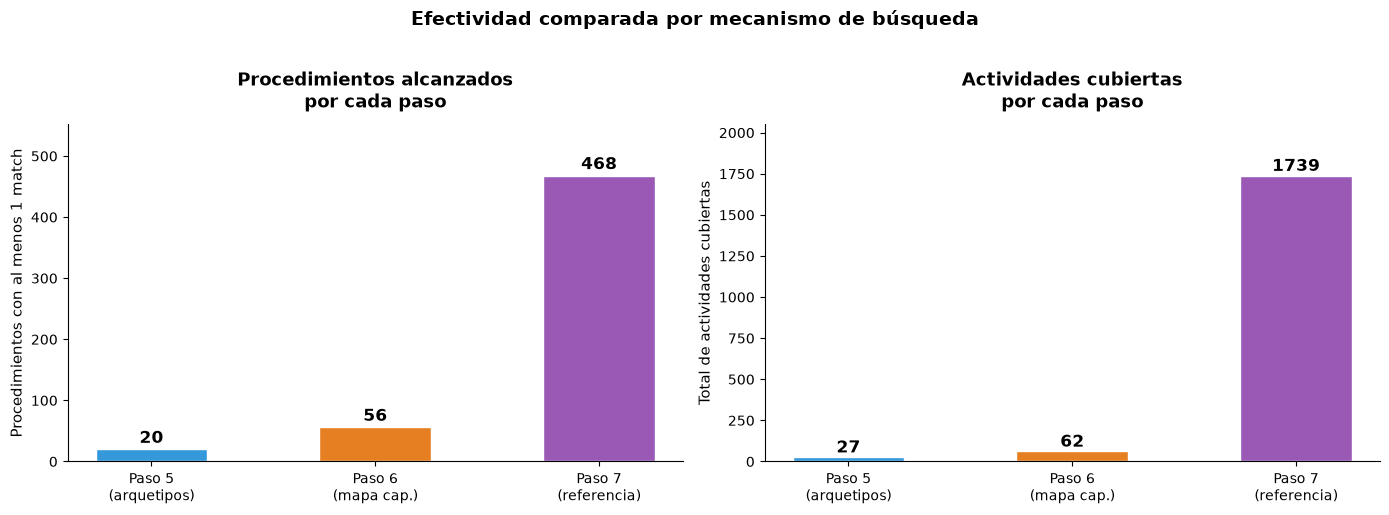

In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pasos  = ['Paso 5\n(arquetipos)', 'Paso 6\n(mapa cap.)', 'Paso 7\n(referencia)']
colors = ['#3498db', '#e67e22', '#9b59b6']

# ── Panel izquierdo: procedimientos con al menos 1 match por paso ─────────────
ax1 = axes[0]
procs_match = [
    (cobertura_global['match paso 5'] > 0).sum(),
    (cobertura_global['match paso 6'] > 0).sum(),
    (cobertura_global['match paso 7'] > 0).sum(),
]
bars1 = ax1.bar(pasos, procs_match, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars1, procs_match):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylabel('Procedimientos con al menos 1 match', fontsize=11)
ax1.set_title('Procedimientos alcanzados\npor cada paso', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylim(0, max(procs_match) * 1.18)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel derecho: actividades cubiertas (suma total) por paso ────────────────
ax2 = axes[1]
acts_match = [
    cobertura_global['match paso 5'].sum(),
    cobertura_global['match paso 6'].sum(),
    cobertura_global['match paso 7'].sum(),
]
bars2 = ax2.bar(pasos, acts_match, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars2, acts_match):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
             str(int(val)), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total de actividades cubiertas', fontsize=11)
ax2.set_title('Actividades cubiertas\npor cada paso', fontsize=13, fontweight='bold', pad=12)
ax2.set_ylim(0, max(acts_match) * 1.18)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Efectividad comparada por mecanismo de búsqueda', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Gráfico 10 — Brecha por proceso: volumen de actividades vs. % cobertura global

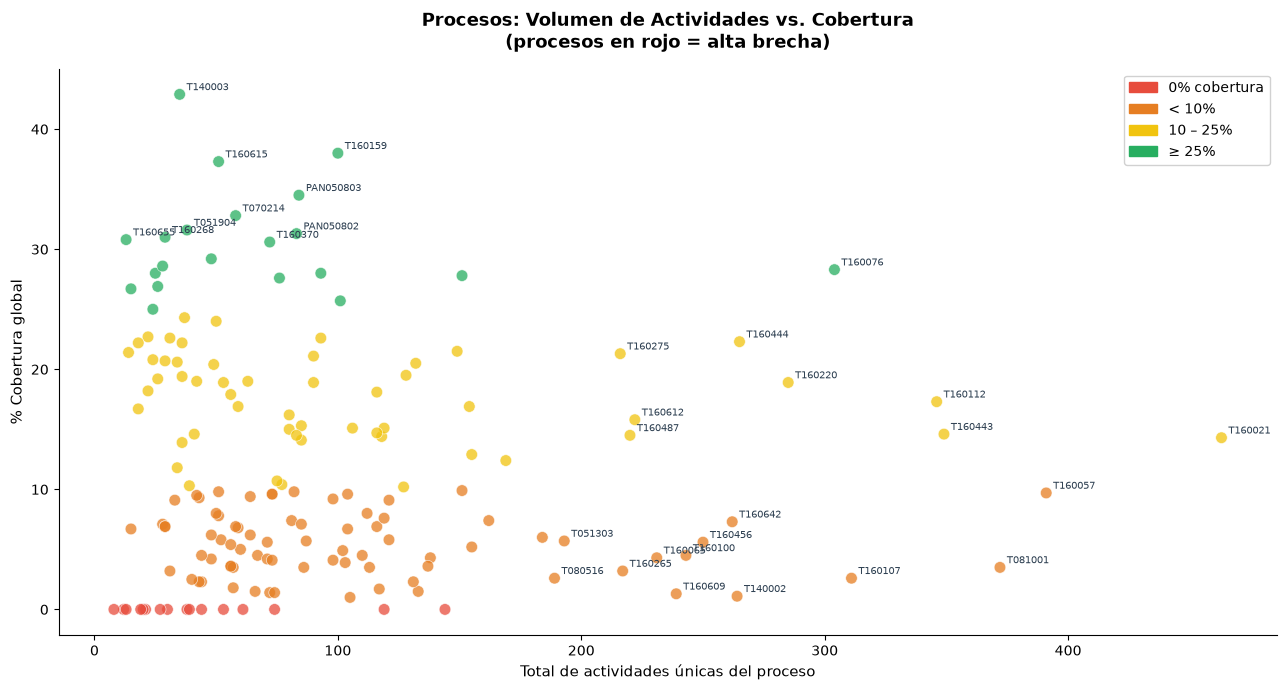

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Agrega por proceso (suma de todos sus procedimientos)
scatter_df = (
    cobertura_global
    .groupby('codigo_proceso')[['total actividades', 'total match']]
    .sum()
    .assign(pct=lambda x: (x['total match'] / x['total actividades'] * 100).round(1))
    .reset_index()
)

def _color(p):
    if p == 0:    return '#e74c3c'
    if p < 10:    return '#e67e22'
    if p < 25:    return '#f1c40f'
    return '#27ae60'

point_colors = scatter_df['pct'].apply(_color)

fig, ax = plt.subplots(figsize=(13, 7))

ax.scatter(
    scatter_df['total actividades'], scatter_df['pct'],
    c=point_colors, s=70, alpha=0.75, edgecolors='white', linewidth=0.5,
)

# Anota los procesos con mayor volumen O mayor cobertura (outliers relevantes)
umbral_vol = scatter_df['total actividades'].quantile(0.88)
umbral_pct = 30
outliers = scatter_df[
    (scatter_df['total actividades'] >= umbral_vol) | (scatter_df['pct'] >= umbral_pct)
]
for _, row in outliers.iterrows():
    ax.annotate(
        row['codigo_proceso'],
        (row['total actividades'], row['pct']),
        fontsize=7.5, xytext=(5, 3), textcoords='offset points', color='#2c3e50',
    )

ax.set_xlabel('Total de actividades únicas del proceso', fontsize=11)
ax.set_ylabel('% Cobertura global', fontsize=11)
ax.set_title('Procesos: Volumen de Actividades vs. Cobertura\n'
             '(procesos en rojo = alta brecha)', fontsize=13, fontweight='bold', pad=15)

legend_handles = [
    mpatches.Patch(color='#e74c3c', label='0% cobertura'),
    mpatches.Patch(color='#e67e22', label='< 10%'),
    mpatches.Patch(color='#f1c40f', label='10 – 25%'),
    mpatches.Patch(color='#27ae60', label='≥ 25%'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Gráfico 11 — Distribución del % de cobertura entre procedimientos (con y sin cobertura)

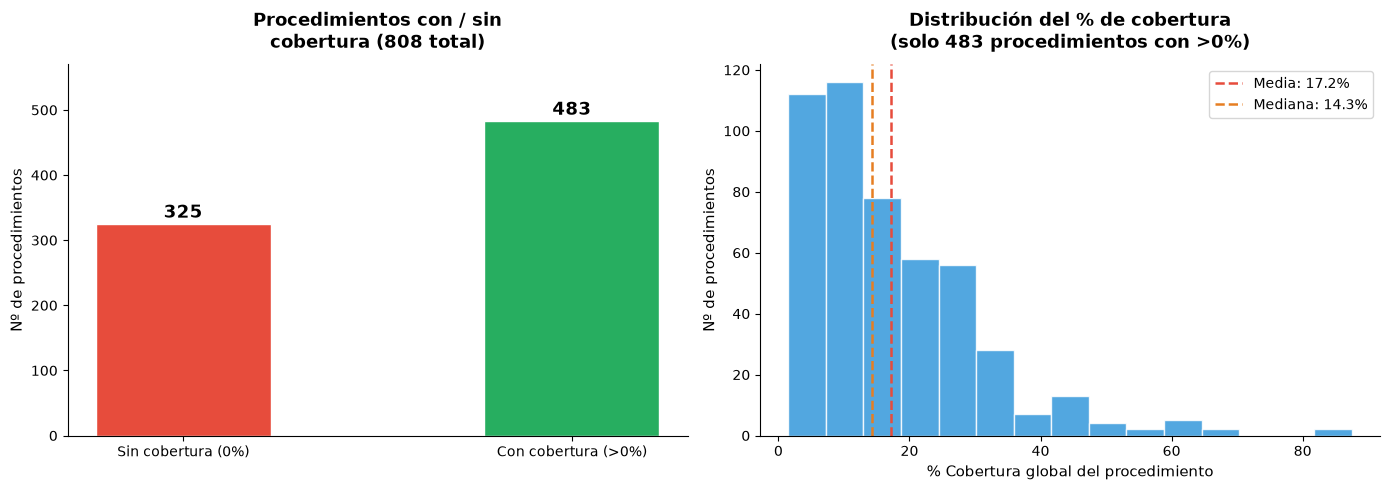

In [37]:
import matplotlib.pyplot as plt
import numpy as np

pct_proc = (
    cobertura_global['total match'] / cobertura_global['total actividades'] * 100
).round(1)

n_cero    = (pct_proc == 0).sum()
n_nonzero = (pct_proc >  0).sum()
pct_pos   = pct_proc[pct_proc > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: con vs sin cobertura ────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(
    ['Sin cobertura (0%)', 'Con cobertura (>0%)'],
    [n_cero, n_nonzero],
    color=['#e74c3c', '#27ae60'], width=0.45, edgecolor='white',
)
for bar, val in zip(bars, [n_cero, n_nonzero]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nº de procedimientos', fontsize=11)
ax1.set_title('Procedimientos con / sin\ncobertura (808 total)', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylim(0, max(n_cero, n_nonzero) * 1.18)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel derecho: histograma solo entre los que tienen cobertura >0% ─────────
ax2 = axes[1]
ax2.hist(pct_pos, bins=15, color='#3498db', edgecolor='white', alpha=0.85)
ax2.axvline(pct_pos.mean(),   color='#e74c3c', linestyle='--', linewidth=1.8,
            label=f'Media: {pct_pos.mean():.1f}%')
ax2.axvline(pct_pos.median(), color='#e67e22', linestyle='--', linewidth=1.8,
            label=f'Mediana: {pct_pos.median():.1f}%')
ax2.set_xlabel('% Cobertura global del procedimiento', fontsize=11)
ax2.set_ylabel('Nº de procedimientos', fontsize=11)
ax2.set_title(f'Distribución del % de cobertura\n(solo {n_nonzero} procedimientos con >0%)',
              fontsize=13, fontweight='bold', pad=12)
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
